# 🧬 Algoritmos Genéticos + Deep Learning

**Aula prática — ~1 hora — Neuroevolução**

---

### 📚 Roteiro

1. **A ideia central** — evolução em vez de gradiente
2. **Os 5 ingredientes de um GA** — população, fitness, seleção, crossover, mutação
3. **Implementação from-scratch** — um GA inteiro em ~30 linhas
4. **Neuroevolução** — uma rede neural aprende a controlar um agente
5. **Visualização** — vendo o agente melhorar geração após geração
6. **🎯 Exercício final**

---

> ✅ **Sem instalação!** Só precisamos de **NumPy, PyTorch e matplotlib** — todos já vêm no Colab. Sem GPU necessária (a rede é pequena de propósito).

> 💡 **Por que essa combinação é interessante?** Algoritmos genéticos são **gradient-free**: funcionam mesmo quando você **não consegue calcular o gradiente** da sua função (ex.: ambientes não-diferenciáveis, recompensas esparsas em RL). É uma alternativa real, não só uma curiosidade.


In [ ]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)
print("✅ Setup pronto")

✅ Setup pronto


---
# 🧠 Parte 1 — A ideia central

### Como redes neurais aprendem normalmente?

Você já conhece o caminho padrão:
1. Calcula a **loss** (erro do modelo)
2. Calcula o **gradiente** da loss em relação aos pesos (backprop)
3. Ajusta os pesos na direção que diminui a loss (SGD/Adam)

Funciona muito bem... **quando o gradiente existe e é calculável**.

### O problema

Em vários cenários, isso quebra:
- 🎮 **Reinforcement Learning** com recompensas raras (o agente quase nunca acerta — gradientes quase sempre zero)
- 🤖 Funções de fitness **não-diferenciáveis** (ex.: número de inimigos derrotados num jogo)
- 🧩 Hiperparâmetros, arquiteturas, estratégias — coisas que você não derivaria

### A ideia da neuroevolução

> *"E se, em vez de calcular o gradiente, eu simplesmente **chutasse muitos conjuntos de pesos diferentes**, ficasse com os melhores, combinasse eles e repetisse?"*

É **evolução biológica aplicada a pesos de rede neural**:
- População = vários conjuntos de pesos
- Fitness = quão bem cada rede se sai na tarefa
- Seleção natural = os melhores "se reproduzem"
- Mutação = pequenas alterações aleatórias

E surpreendentemente, **funciona muito bem**. Empresas como **OpenAI** e **Uber AI** publicaram papers mostrando que neuroevolução compete com SGD em tarefas de RL.


---
# 🧪 Parte 2 — Os 5 ingredientes de um GA

Todo algoritmo genético tem essas 5 peças. Vamos ver cada uma com o exemplo bem simples antes de aplicar a redes.

### 1️⃣ Indivíduo
Uma **solução candidata** ao problema. Pode ser:
- Uma string de bits (problema clássico de otimização)
- Um vetor de números reais ← **vamos usar isso para pesos de rede**
- Uma árvore (programação genética)

### 2️⃣ População
Várias soluções vivendo "ao mesmo tempo". Tipicamente 30-200 indivíduos.

### 3️⃣ Função de fitness
A "régua" que mede o quão **bom** é cada indivíduo. **É aqui que está toda a magia** — defina mal a fitness e o GA otimiza a coisa errada.

### 4️⃣ Seleção
Como escolher quem "se reproduz". Os mais aptos têm mais chance, mas não pode ser determinístico (perde diversidade).

### 5️⃣ Operadores genéticos
- **Crossover**: combinar dois pais para gerar um filho (mistura características boas)
- **Mutação**: pequena alteração aleatória (introduz novidade, escapa de ótimos locais)


### 🎯 Primeiro contato — GA mínimo

Para fixar, vamos resolver um problema bobinho: **achar o vetor `[3, -2, 1, 7, -5]`** sem dar essa resposta ao algoritmo. Ele só sabe medir a distância para esse alvo.


In [ ]:
# ===== GA bem básico para entender o ciclo =====
alvo = np.array([3, -2, 1, 7, -5], dtype=float)

# 1️⃣ Indivíduo: vetor de 5 números reais
# 2️⃣ População: 20 indivíduos aleatórios entre -10 e 10
populacao = [np.random.uniform(-10, 10, size=5) for _ in range(20)]

# 3️⃣ Fitness: quanto MENOR a distância para o alvo, MELHOR
#    (negamos para que "maior fitness = melhor", convenção tradicional)
def fitness(individuo):
    return -np.linalg.norm(individuo - alvo)

# 4️⃣ Seleção por torneio: sorteia k indivíduos, retorna o melhor deles
def torneio(pop, fits, k=3):
    idx = np.random.choice(len(pop), k, replace=False)
    melhor_idx = idx[np.argmax(fits[idx])]
    return pop[melhor_idx]

# 5️⃣ Crossover (média) e mutação (ruído gaussiano)
def crossover(p1, p2):
    return (p1 + p2) / 2

def mutar(ind, intensidade=0.5):
    return ind + np.random.randn(len(ind)) * intensidade

# ===== Loop evolutivo =====
historico_basico = []
for geracao in range(30):
    # Avalia toda a população
    fits = np.array([fitness(ind) for ind in populacao])
    historico_basico.append(fits.max())

    # Cria a próxima geração
    nova_populacao = []
    while len(nova_populacao) < len(populacao):
        pai1 = torneio(populacao, fits)
        pai2 = torneio(populacao, fits)
        filho = crossover(pai1, pai2)
        filho = mutar(filho)
        nova_populacao.append(filho)
    populacao = nova_populacao

# Mostra o melhor
fits_finais = np.array([fitness(ind) for ind in populacao])
melhor = populacao[np.argmax(fits_finais)]
print(f"Alvo procurado:  {alvo}")
print(f"Melhor evoluído: {melhor.round(2)}")
print(f"Distância final: {np.linalg.norm(melhor-alvo):.3f}")

Alvo procurado:  [ 3. -2.  1.  7. -5.]
Melhor evoluído: [ 2.84 -1.98  0.59  6.95 -4.91]
Distância final: 0.453


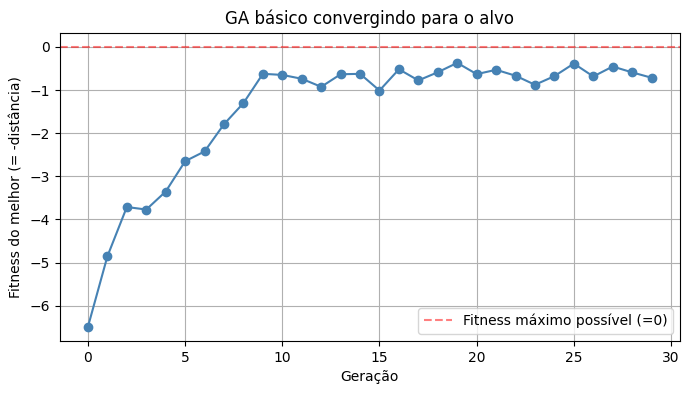

In [ ]:
# Curva de evolução
plt.figure(figsize=(8, 4))
plt.plot(historico_basico, 'o-', color='steelblue')
plt.xlabel('Geração'); plt.ylabel('Fitness do melhor (= -distância)')
plt.title('GA básico convergindo para o alvo')
plt.axhline(0, color='red', linestyle='--', alpha=0.5, label='Fitness máximo possível (=0)')
plt.legend(); plt.grid(True); plt.show()

# 👀 Veja como o fitness sobe rapidamente e depois estabiliza próximo de 0
#    (distância 0 = encontrou exatamente o alvo)

---
# 🤖 Parte 3 — Neuroevolução: o problema

Agora a parte interessante. Vamos fazer um **agente 2D aprender a navegar até um alvo**, controlado por uma pequena rede neural cujos pesos são evoluídos por GA.

### O ambiente

- Mundo 2D simples
- Agente começa em **(0, 0)**
- Alvo fixo em **(5, 5)**
- A cada passo, o agente vê sua **posição** e a do **alvo** e decide quanto se mover em x e y
- Após 50 passos, medimos quão perto chegou

### A rede neural

Uma rede minúscula:
- **Entrada (4)**: `pos_x, pos_y, alvo_x, alvo_y`
- **Camada oculta (8 neurônios)**: ativação `tanh`
- **Saída (2)**: `dx, dy` (direção do movimento, escalada por 0.5)

Total: **58 parâmetros**. Esse vai ser nosso "DNA".

### Por que GA aqui em vez de gradiente?

Como você definiria a loss para usar backprop? Não temos rótulos do tipo "neste estado, mova-se assim". Só temos o objetivo final (chegar perto). Isso é um problema de **controle**, mais parecido com RL. GA resolve isso naturalmente: simulamos, medimos o resultado, evoluímos.


In [ ]:
# ===== Definindo a rede neural =====
class PolicyNet(nn.Module):
    """Rede pequena que decide o movimento do agente."""
    def __init__(self):
        super().__init__()
        # Sequential empilha as camadas. Tanh limita as saídas a [-1, 1].
        self.net = nn.Sequential(
            nn.Linear(4, 8),    # entrada (4) → oculta (8)
            nn.Tanh(),
            nn.Linear(8, 2),    # oculta (8) → saída (2)
            nn.Tanh()
        )

    def forward(self, x):
        return self.net(x)


# Cria uma instância e conta parâmetros
modelo = PolicyNet()
total_params = sum(p.numel() for p in modelo.parameters())
print(f"📊 Rede tem {total_params} parâmetros (esse é o tamanho do nosso 'DNA')")
print(modelo)

📊 Rede tem 58 parâmetros (esse é o tamanho do nosso 'DNA')
PolicyNet(
  (net): Sequential(
    (0): Linear(in_features=4, out_features=8, bias=True)
    (1): Tanh()
    (2): Linear(in_features=8, out_features=2, bias=True)
    (3): Tanh()
  )
)


### 🧬 A ponte rede ↔ vetor

O GA opera em **vetores de números** (mais fácil de mutar e cruzar). Mas o PyTorch guarda os pesos em **tensores espalhados por várias camadas**. Precisamos de duas funções para converter entre os dois mundos:

- `get_weights(modelo)` → vetor numpy
- `set_weights(modelo, vetor)` → injeta o vetor de volta nos tensores


In [ ]:
def get_weights(modelo):
    """Pega todos os pesos do modelo como um único vetor numpy."""
    pedacos = []
    for p in modelo.parameters():
        # .detach() desliga o grafo de gradientes; .flatten() vira 1D
        pedacos.append(p.detach().numpy().flatten())
    return np.concatenate(pedacos)


def set_weights(modelo, vetor):
    """Recebe um vetor numpy e enfia de volta nas camadas do modelo."""
    idx = 0
    for p in modelo.parameters():
        n = p.numel()                              # quantos elementos esse tensor tem
        pedaco = vetor[idx:idx+n].reshape(p.shape) # corta e reformata
        p.data = torch.tensor(pedaco, dtype=torch.float32)
        idx += n


# Sanity check
w_original = get_weights(modelo)
print(f"Vetor de pesos: shape={w_original.shape}, primeiros 5 = {w_original[:5].round(3)}")

# Zera tudo, injeta de volta — confirma que o sistema funciona
set_weights(modelo, np.zeros(total_params))
print(f"Após zerar: primeiros 5 = {get_weights(modelo)[:5]}")

# Restaura o original
set_weights(modelo, w_original)

Vetor de pesos: shape=(58,), primeiros 5 = [ 0.382  0.415 -0.117  0.459 -0.11 ]
Após zerar: primeiros 5 = [0. 0. 0. 0. 0.]


### 🌍 O ambiente: simulando um episódio

A função `simular` roda 50 passos do agente no mundo e devolve a trajetória completa. Reutilizaremos ela tanto para **medir fitness** quanto para **visualizar**.


In [ ]:
ALVO = np.array([5.0, 5.0])     # posição do alvo (fixo)
N_PASSOS = 50                    # quantos passos por episódio


def simular(modelo, alvo=ALVO, n_passos=N_PASSOS):
    """
    Roda um episódio completo. Retorna a trajetória (n_passos+1, 2).
    """
    pos = np.array([0.0, 0.0])                 # começa na origem
    trajetoria = [pos.copy()]

    for _ in range(n_passos):
        # Entrada da rede: posição atual + posição do alvo
        entrada = torch.tensor(
            np.concatenate([pos, alvo]),
            dtype=torch.float32
        )

        # Forward pass (sem gradientes — não vamos treinar com backprop!)
        with torch.no_grad():
            movimento = modelo(entrada).numpy()

        # Aplica o movimento (escalado para passos pequenos)
        pos = pos + movimento * 0.5
        trajetoria.append(pos.copy())

    return np.array(trajetoria)


def fitness_rede(modelo):
    """
    Quanto MAIOR, melhor. Recompensa chegar perto do alvo.
    Fórmula: distância inicial - distância final.
    Se a rede não se mover, fitness = 0. Se chegar exatamente, fitness = dist_inicial.
    """
    traj = simular(modelo)
    dist_inicial = np.linalg.norm(traj[0] - ALVO)
    dist_final = np.linalg.norm(traj[-1] - ALVO)
    return dist_inicial - dist_final


# Testa com rede aleatória
modelo_aleatorio = PolicyNet()
traj_aleatoria = simular(modelo_aleatorio)
fit = fitness_rede(modelo_aleatorio)

print(f"📍 Início: {traj_aleatoria[0]}")
print(f"📍 Fim:    {traj_aleatoria[-1].round(2)}")
print(f"📍 Alvo:   {ALVO}")
print(f"🎯 Fitness: {fit:.2f}  (negativo = piorou; quanto mais positivo, melhor)")

📍 Início: [0. 0.]
📍 Fim:    [-5.05 -7.27]
📍 Alvo:   [5. 5.]
🎯 Fitness: -8.79  (negativo = piorou; quanto mais positivo, melhor)


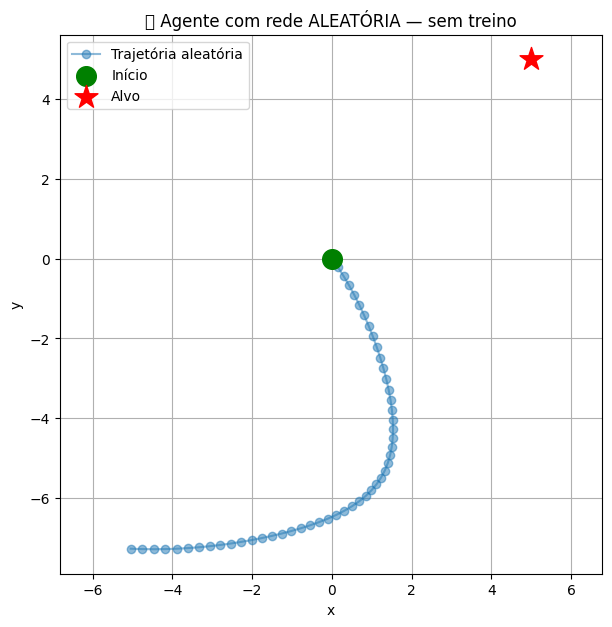

→ Como os pesos são aleatórios, o agente vai pra qualquer lugar. Vamos evoluir isso!


In [ ]:
# Visualiza a trajetória da rede aleatória
plt.figure(figsize=(7, 7))
plt.plot(traj_aleatoria[:, 0], traj_aleatoria[:, 1], 'o-', alpha=0.5, label='Trajetória aleatória')
plt.scatter([0], [0], color='green', s=200, marker='o', label='Início', zorder=5)
plt.scatter([5], [5], color='red',   s=300, marker='*', label='Alvo',   zorder=5)
plt.xlabel('x'); plt.ylabel('y')
plt.title('🤖 Agente com rede ALEATÓRIA — sem treino')
plt.legend(); plt.grid(True); plt.axis('equal')
plt.show()
print("→ Como os pesos são aleatórios, o agente vai pra qualquer lugar. Vamos evoluir isso!")

---
# 🧬 Parte 4 — Evoluindo a rede!

Agora juntamos tudo. O loop é **idêntico** ao GA básico que fizemos antes — só que agora cada indivíduo é um vetor de 58 pesos, e a fitness exige rodar uma simulação inteira.

### Hiperparâmetros do GA

| Parâmetro | Valor | O que faz |
|---|---|---|
| `POPULACAO` | 50 | mais = mais diversidade, mais lento |
| `GERACOES` | 30 | quantos ciclos evolutivos |
| `TAXA_MUTACAO` | 0.1 | chance de cada gene mutar |
| `INTENSIDADE_MUT` | 0.1 | tamanho da perturbação gaussiana |
| `TAMANHO_TORNEIO` | 3 | quantos competem na seleção |


In [ ]:
# ===== Configuração =====
POPULACAO = 50
GERACOES = 30
TAXA_MUTACAO = 0.1
INTENSIDADE_MUT = 0.1
TAMANHO_TORNEIO = 3


# ===== Operadores =====
def crossover_uniforme(p1, p2):
    """Para cada gene, sorteia aleatoriamente de p1 ou p2."""
    mascara = np.random.rand(len(p1)) < 0.5
    return np.where(mascara, p1, p2)


def mutacao_gaussiana(ind, taxa, intensidade):
    """Cada gene tem 'taxa' de chance de receber um ruído gaussiano."""
    mascara = np.random.rand(len(ind)) < taxa
    ruido = np.random.randn(len(ind)) * intensidade
    return ind + mascara * ruido


def torneio_selecao(populacao, fitnesses, k=TAMANHO_TORNEIO):
    """Sorteia k indivíduos e retorna o melhor."""
    indices = np.random.choice(len(populacao), k, replace=False)
    melhor = indices[np.argmax(fitnesses[indices])]
    return populacao[melhor]


# ===== Inicialização =====
modelo_avaliacao = PolicyNet()   # vamos reusar para avaliar todos os indivíduos
populacao = [np.random.randn(total_params) * 0.5 for _ in range(POPULACAO)]

print(f"População inicial criada: {POPULACAO} indivíduos de {total_params} genes cada")

População inicial criada: 50 indivíduos de 58 genes cada


In [ ]:
# ===== Loop evolutivo =====
historico_max = []
historico_med = []

for geracao in range(GERACOES):
    # 1) Avalia toda a população
    fitnesses = np.zeros(POPULACAO)
    for i, individuo in enumerate(populacao):
        set_weights(modelo_avaliacao, individuo)
        fitnesses[i] = fitness_rede(modelo_avaliacao)

    historico_max.append(fitnesses.max())
    historico_med.append(fitnesses.mean())

    # 2) Cria a nova geração
    # ELITISMO: o melhor passa direto, sem alterações
    indice_melhor = np.argmax(fitnesses)
    nova_populacao = [populacao[indice_melhor].copy()]

    # Os outros são filhos de seleção + crossover + mutação
    while len(nova_populacao) < POPULACAO:
        pai1 = torneio_selecao(populacao, fitnesses)
        pai2 = torneio_selecao(populacao, fitnesses)
        filho = crossover_uniforme(pai1, pai2)
        filho = mutacao_gaussiana(filho, TAXA_MUTACAO, INTENSIDADE_MUT)
        nova_populacao.append(filho)

    populacao = nova_populacao

    # Imprime progresso a cada 5 gerações
    if geracao % 5 == 0 or geracao == GERACOES - 1:
        print(f"  Geração {geracao:2d}: melhor fitness = {fitnesses.max():.3f} | médio = {fitnesses.mean():.3f}")

print("\n🎉 Evolução concluída!")

  Geração  0: melhor fitness = 4.782 | médio = -14.307
  Geração  5: melhor fitness = 6.083 | médio = -4.510
  Geração 10: melhor fitness = 6.758 | médio = -0.286
  Geração 15: melhor fitness = 6.758 | médio = 1.456
  Geração 20: melhor fitness = 6.758 | médio = 3.883
  Geração 25: melhor fitness = 7.064 | médio = 4.495
  Geração 29: melhor fitness = 7.064 | médio = 5.074

🎉 Evolução concluída!


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129516 (\N{DNA DOUBLE HELIX}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


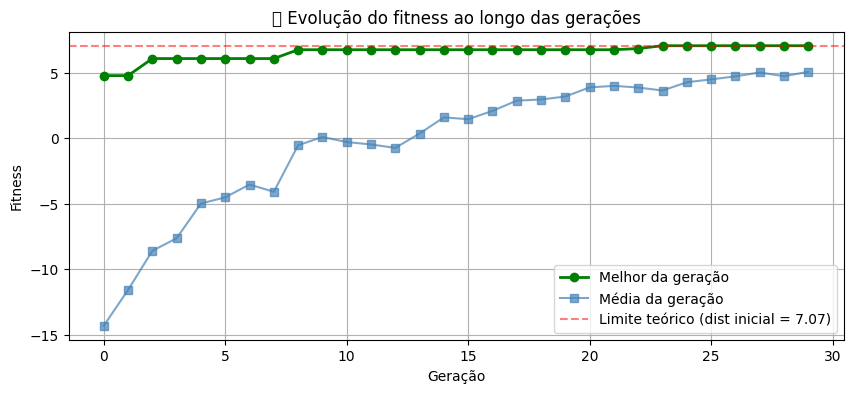

In [ ]:
# ===== Curva de evolução =====
plt.figure(figsize=(10, 4))
plt.plot(historico_max, 'o-', color='green',     label='Melhor da geração', linewidth=2)
plt.plot(historico_med, 's-', color='steelblue', label='Média da geração',  alpha=0.7)
plt.axhline(np.linalg.norm(ALVO), color='red', linestyle='--', alpha=0.5,
            label=f'Limite teórico (dist inicial = {np.linalg.norm(ALVO):.2f})')
plt.xlabel('Geração'); plt.ylabel('Fitness')
plt.title('🧬 Evolução do fitness ao longo das gerações')
plt.legend(); plt.grid(True); plt.show()

---
# 🎬 Parte 5 — Comparando trajetórias: antes e depois

A parte mais legal. Vamos ver a trajetória do **melhor indivíduo evoluído** e comparar com a aleatória inicial.


/tmp/ipykernel_1465/3300786434.py:26: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1465/3300786434.py:26: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


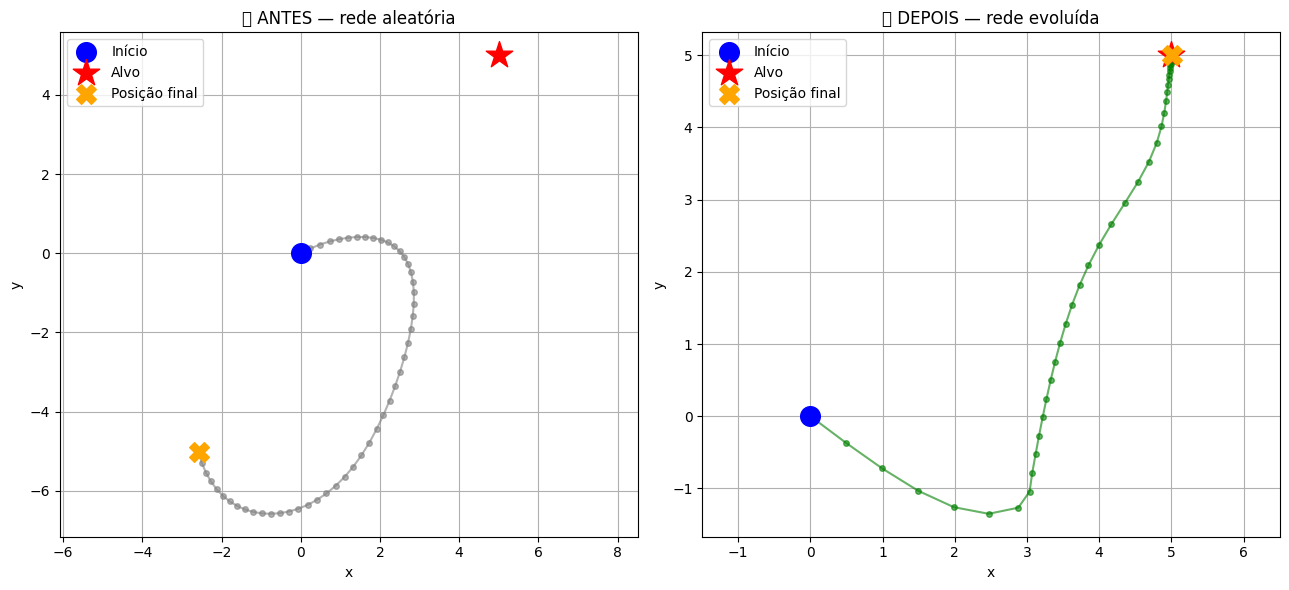

📊 Distância final ANTES:  12.566
📊 Distância final DEPOIS: 0.007


In [ ]:
# Pega o melhor da última geração
fitnesses_finais = np.zeros(POPULACAO)
for i, ind in enumerate(populacao):
    set_weights(modelo_avaliacao, ind)
    fitnesses_finais[i] = fitness_rede(modelo_avaliacao)

melhor_individuo = populacao[np.argmax(fitnesses_finais)]
set_weights(modelo_avaliacao, melhor_individuo)
trajetoria_evoluida = simular(modelo_avaliacao)

# Plota antes vs depois lado a lado
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

for ax, traj, titulo, cor in [
    (axes[0], traj_aleatoria,    '❌ ANTES — rede aleatória',    'gray'),
    (axes[1], trajetoria_evoluida,'✅ DEPOIS — rede evoluída',    'green')
]:
    ax.plot(traj[:, 0], traj[:, 1], 'o-', alpha=0.6, color=cor, markersize=4)
    ax.scatter([0], [0], color='blue', s=200, marker='o', label='Início',  zorder=5)
    ax.scatter([5], [5], color='red',  s=400, marker='*', label='Alvo',    zorder=5)
    ax.scatter(traj[-1, 0], traj[-1, 1], color='orange', s=200, marker='X',
               label='Posição final', zorder=5)
    ax.set_title(titulo); ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.legend(); ax.grid(True); ax.axis('equal')

plt.tight_layout(); plt.show()

print(f"📊 Distância final ANTES:  {np.linalg.norm(traj_aleatoria[-1]    - ALVO):.3f}")
print(f"📊 Distância final DEPOIS: {np.linalg.norm(trajetoria_evoluida[-1] - ALVO):.3f}")

### 🎯 Generalização: e se mudarmos o alvo?

Olha que interessante. Treinamos a rede só com o alvo fixo em **(5, 5)**. Será que ela aprendeu **a regra** ("vá em direção ao alvo, seja qual for") ou só **decorou** ir para (5, 5)?

Vamos testar com alvos diferentes que ela **nunca viu durante o treino**.


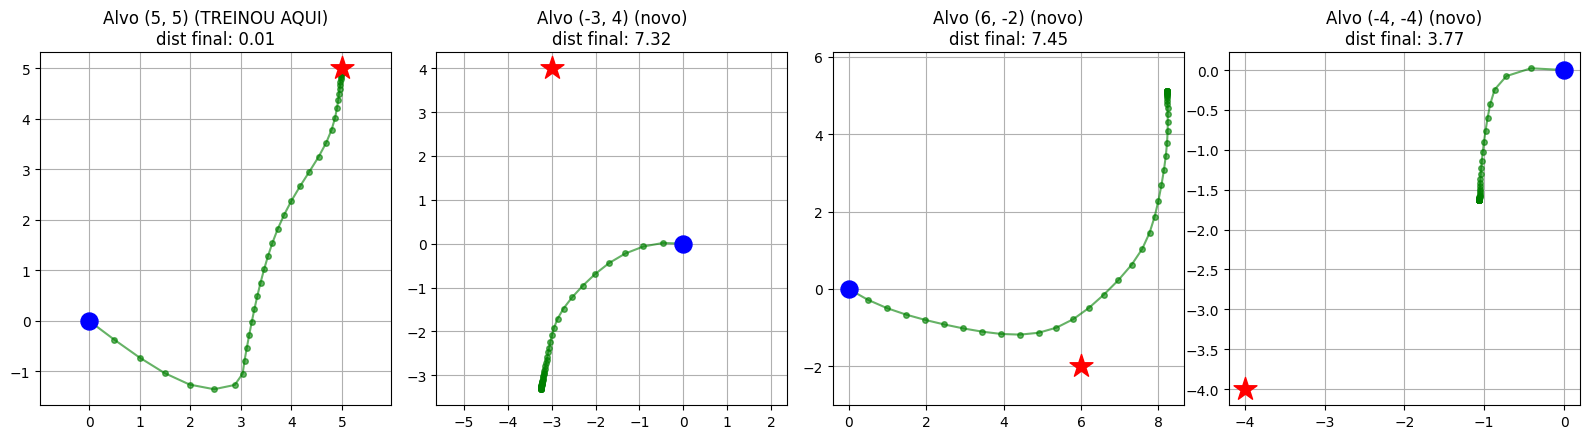

→ Se a rede chega bem em alvos que NUNCA viu, ela GENERALIZOU a regra,
  não decorou. Esse é o sinal de que a rede 'entendeu' o problema.


In [ ]:
# Testa com 4 alvos diferentes
alvos_teste = [(5, 5), (-3, 4), (6, -2), (-4, -4)]

fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))

for ax, alvo in zip(axes, alvos_teste):
    traj = simular(modelo_avaliacao, alvo=np.array(alvo, dtype=float))
    ax.plot(traj[:, 0], traj[:, 1], 'o-', alpha=0.6, color='green', markersize=4)
    ax.scatter([0], [0],         color='blue',  s=150, marker='o', zorder=5)
    ax.scatter([alvo[0]], [alvo[1]], color='red', s=300, marker='*', zorder=5)
    dist = np.linalg.norm(traj[-1] - np.array(alvo))
    treinado = '(TREINOU AQUI)' if alvo == (5, 5) else '(novo)'
    ax.set_title(f'Alvo {alvo} {treinado}\ndist final: {dist:.2f}')
    ax.grid(True); ax.axis('equal')

plt.tight_layout(); plt.show()

print("→ Se a rede chega bem em alvos que NUNCA viu, ela GENERALIZOU a regra,")
print("  não decorou. Esse é o sinal de que a rede 'entendeu' o problema.")

---
# 🎓 GA vs Gradient Descent — quando usar cada um?

| Critério | Backprop / SGD | Algoritmo Genético |
|---|---|---|
| **Velocidade** | 🟢 Rápido (1 forward + 1 backward) | 🔴 Lento (avalia população toda) |
| **Precisa de gradiente?** | Sim | Não |
| **Funciona com loss não-diferenciável?** | Não | Sim |
| **Paralelização** | Limitada (sequencial nas épocas) | Trivial (cada indivíduo é independente) |
| **Escapa de mínimos locais?** | Difícil | Mais fácil (diversidade da população) |
| **Funciona com milhões de parâmetros?** | Sim, fácil | Difícil (espaço de busca cresce demais) |

### 🏆 Onde GA / neuroevolução brilha de verdade

- **Reinforcement Learning** com recompensas raras (gradientes inúteis)
- **Search neural architecture** (NAS): qual a melhor arquitetura?
- **Otimização de hiperparâmetros**
- **Combinatorial problems** (caixeiro-viajante, scheduling)

### 📖 Para se aprofundar

- *Deep Neuroevolution: Genetic Algorithms Are a Competitive Alternative for Training Deep Neural Networks for Reinforcement Learning* (Uber AI, 2017)
- *Evolution Strategies as a Scalable Alternative to Reinforcement Learning* (OpenAI, 2017)
- **NEAT** (NeuroEvolution of Augmenting Topologies): também evolui a **arquitetura** da rede, não só os pesos


---
# 📝 Resumo da aula

✅ **Algoritmos Genéticos** têm 5 ingredientes: indivíduo, população, fitness, seleção, operadores (crossover + mutação)

✅ **Neuroevolução** = usar GA para encontrar pesos de redes neurais

✅ **Útil quando** não há gradiente (RL, métricas discretas) ou quando você quer paralelizar massivamente

✅ Implementamos um GA do zero em ~30 linhas

✅ Uma rede com **apenas 58 parâmetros** aprendeu a navegar até um alvo, e **generalizou** para alvos que nunca viu


---
# 🎯 Exercício Final

Agora você vai estender o sistema!

### Parte A — Obstáculo no caminho (40 pontos)
1. Modifique o ambiente para que haja um **obstáculo circular** no meio do caminho (ex.: centro em `(2.5, 2.5)`, raio `1.0`).
2. Modifique a **fitness** para **penalizar** trajetórias que passem dentro do obstáculo. Sugestão:
   ```python
   penalidade = soma(distancias_dentro_do_obstaculo) * 0.5
   fitness = (dist_inicial - dist_final) - penalidade
   ```
3. Aumente a entrada da rede para receber também a posição e o raio do obstáculo (passa de 4 para 7 entradas).
4. Treine e plote a trajetória final. O agente desvia?

### Parte B — Comparação de hiperparâmetros (30 pontos)
Treine **3 vezes** com configurações diferentes e compare as curvas de evolução num mesmo gráfico:
1. Mutação fraca (`TAXA_MUTACAO=0.05`, `INTENSIDADE_MUT=0.05`)
2. Mutação média (a do notebook)
3. Mutação forte (`TAXA_MUTACAO=0.3`, `INTENSIDADE_MUT=0.5`)

Em qual a evolução foi mais estável? Em qual chegou mais rápido a uma boa solução? Faz sentido?

### Parte C — Crossover diferente (20 pontos)
Implemente o **crossover de ponto único** (escolhe um índice aleatório e junta a primeira metade de um pai com a segunda metade do outro). Compare com o crossover uniforme. Para essa tarefa, qual funcionou melhor?

### Parte D — Reflexão (10 pontos)
Em markdown, responda:
1. Por que você acha que essa rede **conseguiu generalizar** para alvos novos, mesmo treinando só em (5, 5)?
2. Se a rede tivesse 10 milhões de parâmetros em vez de 58, o GA ainda seria uma boa escolha? Por quê?
3. **Bônus:** pesquise o que é **Evolution Strategies** (ES) — a variante do OpenAI. Em 1 parágrafo, explique a principal diferença para o GA clássico.

---

### 💡 Dicas
- Reaproveite todas as funções do notebook — só ajuste o que mudou.
- Para o obstáculo, faça a entrada da rede ser `[pos_x, pos_y, alvo_x, alvo_y, obs_x, obs_y, obs_raio]`.
- Lembre de mudar o `nn.Linear(4, 8)` para `nn.Linear(7, 8)` se aumentar as entradas!


In [ ]:
# ============================================================
# 🎯 SEU CÓDIGO COMEÇA AQUI
# ============================================================

# Parte A — Obstáculo no caminho
# Dica 1: defina OBSTACULO = (centro_x, centro_y, raio)
# Dica 2: modifique simular() para registrar quando o agente está dentro do obstáculo
# Dica 3: PolicyNet precisa de nn.Linear(7, 8) na primeira camada





In [ ]:
# Parte B — Comparação de hiperparâmetros (3 treinos, 3 curvas no mesmo gráfico)





In [ ]:
# Parte C — Crossover de ponto único





## Parte D — Sua reflexão

*(escreva suas respostas em markdown)*

**1. Por que a rede generalizou para alvos novos?**

> Sua resposta...

**2. GA seria boa escolha com 10 milhões de parâmetros?**

> Sua resposta...

**3. Bônus — Evolution Strategies:**

> Sua resposta...
